# AutoEncoders

In [1]:
from tensorflow.keras import layers, Sequential, optimizers, metrics, activations, losses, regularizers, Model
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from sklearn.manifold import TSNE
from collections import Counter


sns.set_style('whitegrid')

# PCA with a linear Autoencoder

In [2]:
# Build 3D dataset:

np.random.seed(4)

def generate_3d_data(m, w1=0.1, w2=0.3, noise=0.1):
    angles = np.random.rand(m) * 3 * np.pi / 2 - 0.5
    data = np.empty((m, 3))
    data[:, 0] = np.cos(angles) + np.sin(angles)/2 + noise * np.random.randn(m) / 2
    data[:, 1] = np.sin(angles) * 0.7 + noise * np.random.randn(m) / 2
    data[:, 2] = data[:, 0] * w1 + data[:, 1] * w2 + noise * np.random.randn(m)
    return data

X_train = generate_3d_data(60)
X_train = X_train - X_train.mean(axis=0, keepdims=False)

In [5]:
encoder = Sequential([
    layers.Input(shape=(3,)),
    layers.Dense(2, activation='relu'),
])

decoder = Sequential([
    layers.Input(shape=(2,)),
    layers.Dense(3, activation='sigmoid'),
])

autoencoder = Sequential([encoder, decoder])

autoencoder.compile(optimizer='adam', loss='mse')

history = autoencoder.fit(X_train, X_train, epochs=50, batch_size=32)
codings = encoder.predict(X_train)

Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 0.5410
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.5402 
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.5393
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - loss: 0.5385
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.5376 
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.5368 
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.5359
Epoch 8/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 0.5350 
Epoch 9/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.5341
Epoch 10/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.5331
Epoch 11/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.5321 
Epoch 12/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.5313 
Epoch 13/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 0.5303
Epoch 14/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.5293 
Epoch 15/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.5284
Epoch 16/50
2/2 ━━━━━━━━━━━

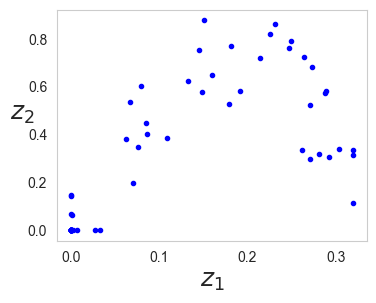

In [11]:
fig = plt.figure(figsize=(4,3))
plt.plot(codings[:,0], codings[:, 1], "b.")
plt.xlabel("$z_1$", fontsize=18)
plt.ylabel("$z_2$", fontsize=18, rotation=0)
plt.grid(False)
# save_fig("linear_autoencoder_pca_plot")
plt.show()

# Multi-layer AutoEncoder

In [3]:
from tensorflow.datasets import fashion_mnist

(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()
X_train_full = X_train_full.astype(np.float32) / 255
X_test = X_test.astype(np.float32) / 255
X_train, X_valid = X_train_full[:-5000], X_train_full[-5000:]
y_train, y_valid = y_train_full[:-5000], y_train_full[-5000:]

In [4]:
def rounded_accuracy(y_true, y_pred):
    return metrics.binary_accuracy(tf.round(y_true), tf.round(y_pred))

In [27]:
stacked_encoder = Sequential([
    layers.Input(shape=(28,28)),
    layers.Flatten(),
    layers.Dense(100, activation='selu'),
    layers.Dense(30, activation='selu'),
])

stacked_decoder = Sequential([
    layers.Input(shape=(30,)),
    layers.Dense(100, activation='selu'),
    layers.Dense(28*28, activation='sigmoid'),
    layers.Reshape((28,28)),
])

stacked_ae = Sequential([stacked_encoder, stacked_decoder])

stacked_ae.compile(loss="binary_crossentropy",
                   optimizer=optimizers.SGD(learning_rate=1.5), metrics=[rounded_accuracy])
history = stacked_ae.fit(X_train, X_train, epochs=10,
                         validation_data=(X_valid, X_valid))

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.3367 - rounded_accuracy: 0.8881 - val_loss: 0.3134 - val_rounded_accuracy: 0.9068
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.3061 - rounded_accuracy: 0.9146 - val_loss: 0.3027 - val_rounded_accuracy: 0.9192
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.2993 - rounded_accuracy: 0.9208 - val_loss: 0.2986 - val_rounded_accuracy: 0.9252
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.2951 - rounded_accuracy: 0.9245 - val_loss: 0.2953 - val_rounded_accuracy: 0.9240
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.2927 - rounded_accuracy: 0.9267 - val_loss: 0.2932 - val_rounded_accuracy: 0.9279
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.2909 - rounded_accuracy: 0.9283 - val_loss: 0.2911 - val_rounded_accuracy: 0.9305
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.2895 - rounded_accuracy: 0.9295 - val_loss: 0.2903 - val_rou

# Result Visualization

In [5]:
def plot_image(image):
    plt.imshow(image, cmap='gray')
    plt.axis('off')

def show_reconstructions(model, images=X_valid, n_images=15):
    reconstructions = model.predict(images[:n_images])
    fig = plt.figure(figsize=(n_images * 1.5, 3))
    for image_index in range(n_images):
        plt.subplot(2, n_images, 1 + image_index)
        plot_image(images[image_index])
        plt.subplot(2, n_images, 1 + n_images + image_index)
        plot_image(reconstructions[image_index])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step


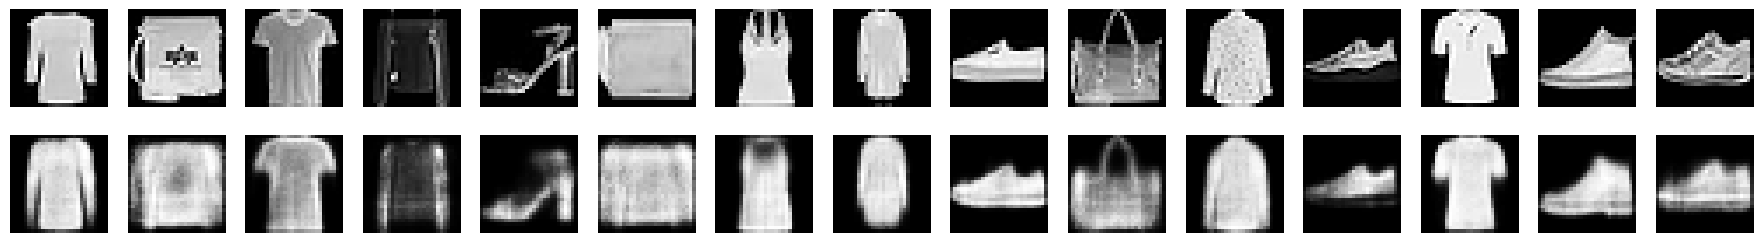

In [29]:
show_reconstructions(stacked_ae)

# Visualizing Fashion MNIST

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


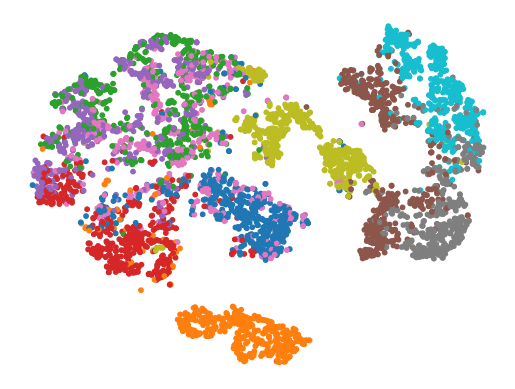

In [31]:
np.random.seed(42)

X_valid_compressed = stacked_encoder.predict(X_valid)
tsne = TSNE()
X_valid_2D = tsne.fit_transform(X_valid_compressed)
X_valid_2D = (X_valid_2D - X_valid_2D.min()) / (X_valid_2D.max() - X_valid_2D.min())
plt.scatter(X_valid_2D[:, 0], X_valid_2D[:, 1], c=y_valid, s=10, cmap="tab10")
plt.axis("off")
plt.show()

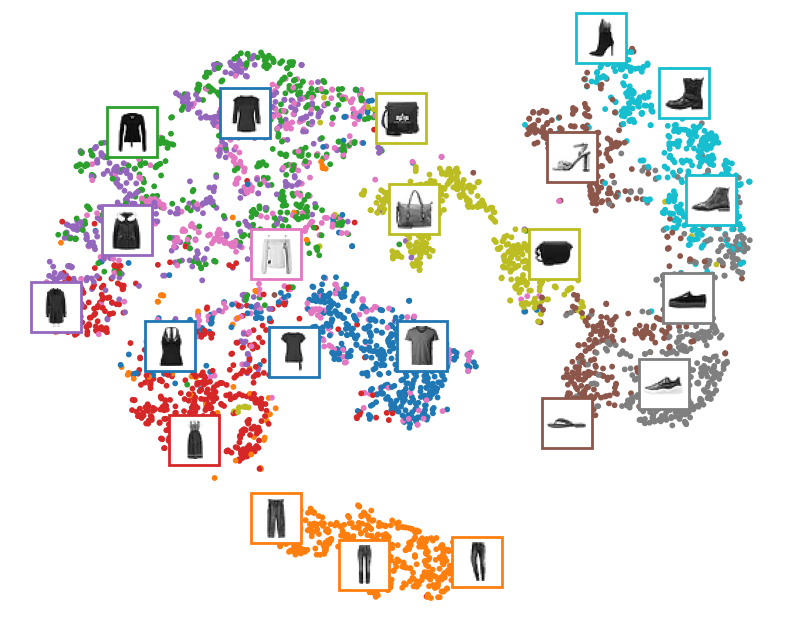

In [34]:
# Let's make this diagram a bit prettier:

# adapted from https://scikit-learn.org/stable/auto_examples/manifold/plot_lle_digits.html
plt.figure(figsize=(10, 8))
cmap = plt.cm.tab10
plt.scatter(X_valid_2D[:, 0], X_valid_2D[:, 1], c=y_valid, s=10, cmap=cmap)
image_positions = np.array([[1., 1.]])
for index, position in enumerate(X_valid_2D):
    dist = np.sum((position - image_positions) ** 2, axis=1)
    if np.min(dist) > 0.02: # if far enough from other images
        image_positions = np.r_[image_positions, [position]]
        imagebox = mpl.offsetbox.AnnotationBbox(
            mpl.offsetbox.OffsetImage(X_valid[index], cmap="binary"),
            position, bboxprops={"edgecolor": cmap(y_valid[index]), "lw": 2})
        plt.gca().add_artist(imagebox)
plt.axis("off")
plt.show()

# Tying weights
It is common to tie the weights of the encoder and the decoder, by simply using the transpose of the encoder's weights as the decoder weights. For this, we need to use a custom layer.

In [40]:
class DenseTranspose(layers.Layer):
    def __init__(self, dense, activation=None, **kwargs):
        super().__init__(**kwargs)
        self.dense = dense
        self.activation = activations.get(activation)

    def build(self, batch_input_shape):
        # kernel shape: (input_dim, output_dim)
        input_dim = int(self.dense.kernel.shape[0])
        self.biases = self.add_weight(
            name="bias",
            shape=(input_dim,),
            initializer="zeros",
            trainable=True,
        )
        super().build(batch_input_shape)

    def call(self, inputs):
        # transpose of encoder weights
        z = tf.matmul(inputs, self.dense.kernel, transpose_b=True)
        z = z + self.biases
        if self.activation is not None:
            z = self.activation(z)
        return z

In [41]:
tf.backend.clear_session()
tf.random.set_seed(42)
np.random.seed(42)

dense_1 = layers.Dense(100, activation="selu")
dense_2 = layers.Dense(30, activation="selu")

tied_encoder = Sequential([
    layers.Input(shape=(28,28)),
    layers.Flatten(),
    dense_1,
    dense_2
])

tied_decoder = Sequential([
    DenseTranspose(dense_2, activation="selu"),
    DenseTranspose(dense_1, activation="sigmoid"),
    layers.Reshape([28, 28])
])

tied_ae = Sequential([tied_encoder, tied_decoder])

tied_ae.compile(loss="binary_crossentropy",
                optimizer=optimizers.SGD(learning_rate=1.5), metrics=[rounded_accuracy])
history = tied_ae.fit(X_train, X_train, epochs=10,
                      validation_data=(X_valid, X_valid))

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.3272 - rounded_accuracy: 0.8956 - val_loss: 0.3058 - val_rounded_accuracy: 0.9105
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.2975 - rounded_accuracy: 0.9222 - val_loss: 0.2984 - val_rounded_accuracy: 0.9171
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 0.2914 - rounded_accuracy: 0.9281 - val_loss: 0.2904 - val_rounded_accuracy: 0.9311
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 0.2882 - rounded_accuracy: 0.9311 - val_loss: 0.2882 - val_rounded_accuracy: 0.9330
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.2861 - rounded_accuracy: 0.9330 - val_loss: 0.2868 - val_rounded_accuracy: 0.9339
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.2846 - rounded_accuracy: 0.9344 - val_loss: 0.2855 - val_rounded_accuracy: 0.9355
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.2835 - rounded_accuracy: 0.9354 - val_loss: 0.2845 - val_r

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step


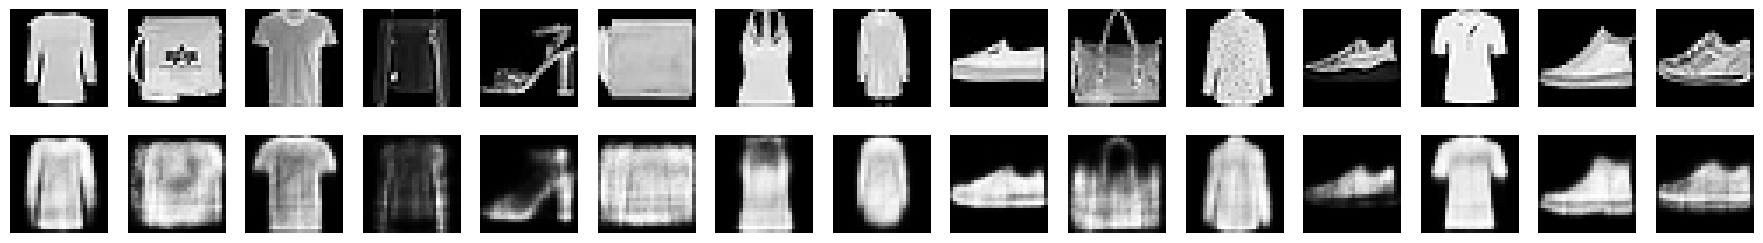

In [42]:
show_reconstructions(tied_ae)
plt.show()

# Training one Autoencoder at a Time

In [43]:
def train_autoencoder(n_neurons, X_train, X_valid, loss, optimizer,
                      n_epochs=10, output_activation=None, metrics=None):
    n_inputs = X_train.shape[-1]
    encoder = Sequential([
        layers.Input(shape=[n_inputs]),
        layers.Dense(n_neurons, activation="selu")
    ])
    decoder = Sequential([
        layers.Dense(n_inputs, activation=output_activation),
    ])
    autoencoder = Sequential([encoder, decoder])
    autoencoder.compile(optimizer, loss, metrics=metrics)
    autoencoder.fit(X_train, X_train, epochs=n_epochs,
                    validation_data=(X_valid, X_valid))
    return encoder, decoder, encoder(X_train), encoder(X_valid)

In [44]:
tf.random.set_seed(42)
np.random.seed(42)

K = tf.backend
X_train_flat = K.batch_flatten(X_train) # equivalent to .reshape(-1, 28 * 28)
X_valid_flat = K.batch_flatten(X_valid)

enc1, dec1, X_train_enc1, X_valid_enc1 = train_autoencoder(
    100, X_train_flat, X_valid_flat, "binary_crossentropy",
    optimizers.SGD(learning_rate=1.5), output_activation="sigmoid",
    metrics=[rounded_accuracy])
enc2, dec2, _, _ = train_autoencoder(
    30, X_train_enc1, X_valid_enc1, "mse", optimizers.SGD(learning_rate=0.05),
    output_activation="selu")

Epoch 1/10


C:\Users\Tymur_Hilfatullin\Projects\ML\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.3445 - rounded_accuracy: 0.8875 - val_loss: 0.3121 - val_rounded_accuracy: 0.9148
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.3039 - rounded_accuracy: 0.9204 - val_loss: 0.3009 - val_rounded_accuracy: 0.9240
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.2954 - rounded_accuracy: 0.9282 - val_loss: 0.2940 - val_rounded_accuracy: 0.9307
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.2897 - rounded_accuracy: 0.9336 - val_loss: 0.2895 - val_rounded_accuracy: 0.9352
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.2860 - rounded_accuracy: 0.9372 - val_loss: 0.2865 - val_rounded_accuracy: 0.9382
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.2835 - rounded_accuracy: 0.9397 - val_loss: 0.2843 - val_rounded_accuracy: 0.9404
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.2815 - rounded_accuracy: 0.9416 - val_loss: 0.2825 - val_rounded_accura

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


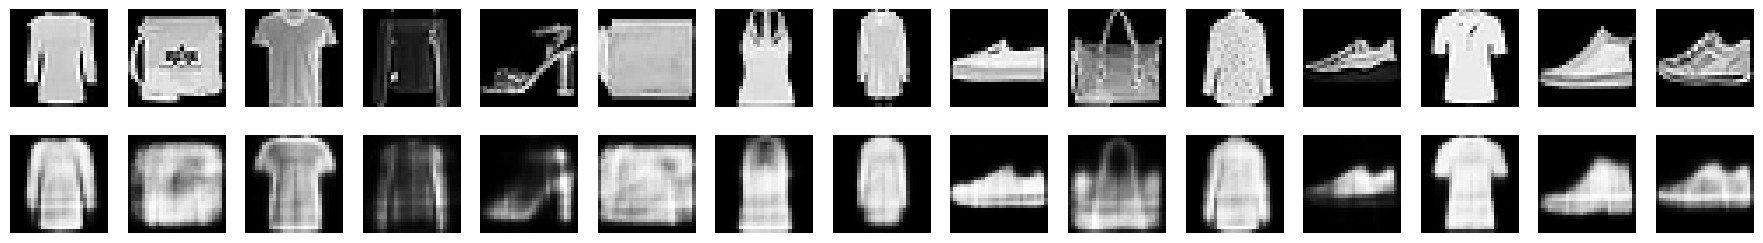

In [46]:
stacked_ae_1_by_1 = Sequential([
    layers.Flatten(input_shape=[28, 28]),
    enc1, enc2, dec2, dec1,
    layers.Reshape([28, 28])
])
show_reconstructions(stacked_ae_1_by_1)
plt.show()

In [47]:
stacked_ae_1_by_1.compile(loss="binary_crossentropy",
                          optimizer=optimizers.SGD(learning_rate=0.1),
                          metrics=[rounded_accuracy])

history = stacked_ae_1_by_1.fit(X_train, X_train, epochs=10,
                                validation_data=(X_valid, X_valid))

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - loss: 0.2861 - rounded_accuracy: 0.9350 - val_loss: 0.2878 - val_rounded_accuracy: 0.9353
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.2858 - rounded_accuracy: 0.9354 - val_loss: 0.2875 - val_rounded_accuracy: 0.9355
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.2856 - rounded_accuracy: 0.9356 - val_loss: 0.2874 - val_rounded_accuracy: 0.9357
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.2854 - rounded_accuracy: 0.9358 - val_loss: 0.2872 - val_rounded_accuracy: 0.9358
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 0.2853 - rounded_accuracy: 0.9359 - val_loss: 0.2871 - val_rounded_accuracy: 0.9360
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.2852 - rounded_accuracy: 0.9360 - val_loss: 0.2870 - val_rounded_accuracy: 0.9361
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.2850 - rounded_accuracy: 0.9361 - val_loss: 0.2869 - val_r

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step


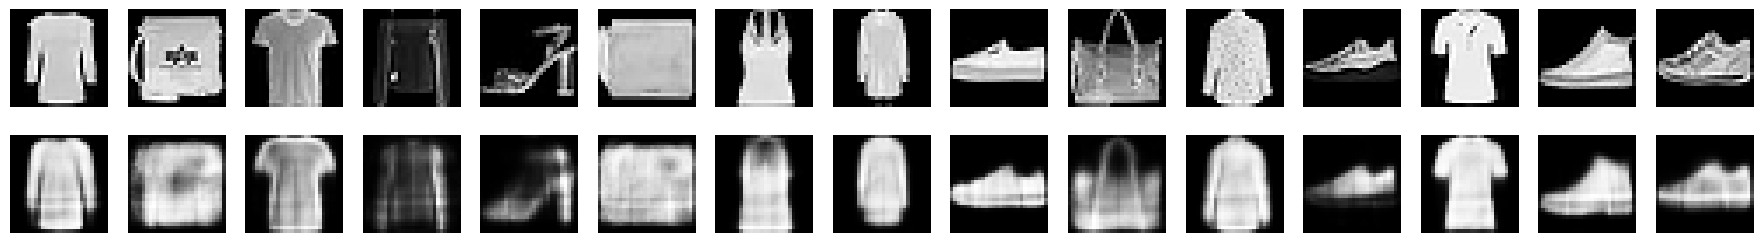

In [48]:
show_reconstructions(stacked_ae_1_by_1)
plt.show()

# Using Convolutional Layers Instead of Dense Layers

In [49]:
tf.random.set_seed(42)
np.random.seed(42)

conv_encoder = Sequential([
    layers.Input(shape=[28, 28]),
    layers.Reshape([28, 28, 1]),
    layers.Conv2D(16, kernel_size=3, padding="SAME", activation="selu"),
    layers.MaxPool2D(pool_size=2),
    layers.Conv2D(32, kernel_size=3, padding="SAME", activation="selu"),
    layers.MaxPool2D(pool_size=2),
    layers.Conv2D(64, kernel_size=3, padding="SAME", activation="selu"),
    layers.MaxPool2D(pool_size=2)
])
conv_decoder = Sequential([
    layers.Conv2DTranspose(32, kernel_size=3, strides=2, padding="VALID", activation="selu",
                                 input_shape=[3, 3, 64]),
    layers.Conv2DTranspose(16, kernel_size=3, strides=2, padding="SAME", activation="selu"),
    layers.Conv2DTranspose(1, kernel_size=3, strides=2, padding="SAME", activation="sigmoid"),
    layers.Reshape([28, 28])
])
conv_ae = Sequential([conv_encoder, conv_decoder])

conv_ae.compile(loss="binary_crossentropy", optimizer=optimizers.SGD(learning_rate=1.0),
                metrics=[rounded_accuracy])

history = conv_ae.fit(X_train, X_train, epochs=5,
                      validation_data=(X_valid, X_valid))

C:\Users\Tymur_Hilfatullin\Projects\ML\.venv\Lib\site-packages\keras\src\layers\reshaping\reshape.py:38: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
C:\Users\Tymur_Hilfatullin\Projects\ML\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv_transpose.py:94: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(


Epoch 1/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 23s 13ms/step - loss: 0.3004 - rounded_accuracy: 0.9202 - val_loss: 0.2814 - val_rounded_accuracy: 0.9393
Epoch 2/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - loss: 0.2756 - rounded_accuracy: 0.9415 - val_loss: 0.2750 - val_rounded_accuracy: 0.9425
Epoch 3/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - loss: 0.2711 - rounded_accuracy: 0.9461 - val_loss: 0.2715 - val_rounded_accuracy: 0.9464
Epoch 4/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - loss: 0.2686 - rounded_accuracy: 0.9487 - val_loss: 0.2688 - val_rounded_accuracy: 0.9494
Epoch 5/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - loss: 0.2669 - rounded_accuracy: 0.9505 - val_loss: 0.2671 - val_rounded_accuracy: 0.9515


In [50]:
conv_encoder.summary()
conv_decoder.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape_2 (Reshape)             │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 64)       │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,296 (91.00 KB)

 Trainable params: 23,296 (91.00 KB)

 Non-trainable params: 0 (0.00 B)

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_transpose                │ (None, 7, 7, 32)       │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 14, 14, 16)     │         4,624 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 1)      │           145 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_3 (Reshape)             │ (None, 28, 28)         │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,233 (90.75 KB)

 Trainable params: 23,233 (90.75 KB)

 Non-trainable params: 0 (0.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step


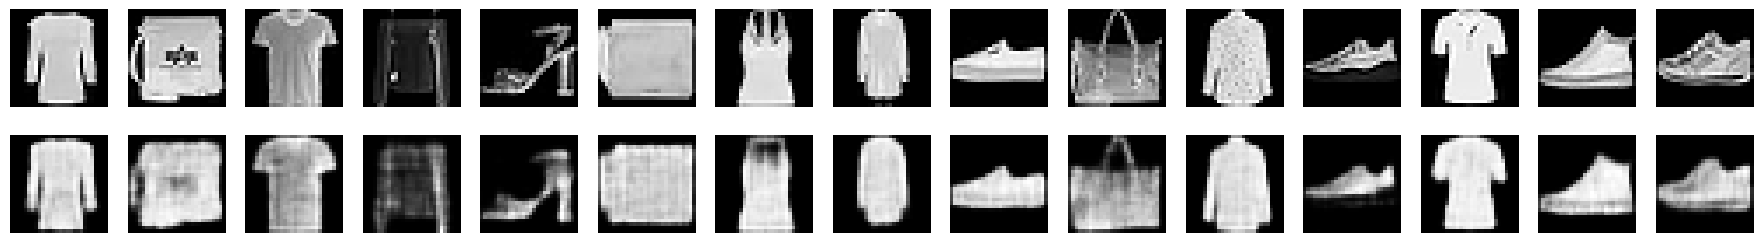

In [51]:
show_reconstructions(conv_ae)
plt.show()

# Recurrent Autoencoders

In [52]:
recurrent_encoder = Sequential([
    layers.Input(shape=[28, 28]),
    layers.LSTM(100, return_sequences=True),
    layers.LSTM(30)
])

recurrent_decoder = Sequential([
    layers.Input(shape=[30]),
    layers.RepeatVector(28),
    layers.LSTM(100, return_sequences=True),
    layers.TimeDistributed(layers.Dense(28, activation="sigmoid"))
])

recurrent_ae = Sequential([recurrent_encoder, recurrent_decoder])

recurrent_ae.compile(loss="binary_crossentropy",
                     optimizer=optimizers.SGD(0.1),
                     metrics=[rounded_accuracy])

history = recurrent_ae.fit(X_train, X_train,
                           epochs=10,
                           validation_data=(X_valid, X_valid))

C:\Users\Tymur_Hilfatullin\Projects\ML\.venv\Lib\site-packages\keras\src\layers\reshaping\repeat_vector.py:29: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 102s 50ms/step - loss: 0.5001 - rounded_accuracy: 0.7657 - val_loss: 0.4315 - val_rounded_accuracy: 0.8152
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 79s 46ms/step - loss: 0.3939 - rounded_accuracy: 0.8489 - val_loss: 0.3746 - val_rounded_accuracy: 0.8650
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 64s 37ms/step - loss: 0.3631 - rounded_accuracy: 0.8725 - val_loss: 0.3587 - val_rounded_accuracy: 0.8767
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 60s 35ms/step - loss: 0.3506 - rounded_accuracy: 0.8816 - val_loss: 0.3477 - val_rounded_accuracy: 0.8857
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 126s 73ms/step - loss: 0.3395 - rounded_accuracy: 0.8886 - val_loss: 0.3351 - val_rounded_accuracy: 0.8918
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 122s 71ms/step - loss: 0.3321 - rounded_accuracy: 0.8933 - val_loss: 0.3374 - val_rounded_accuracy: 0.8931
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 60s 35ms/step - loss: 0.3269 - rounded_accuracy: 0.8971 - val_loss:

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


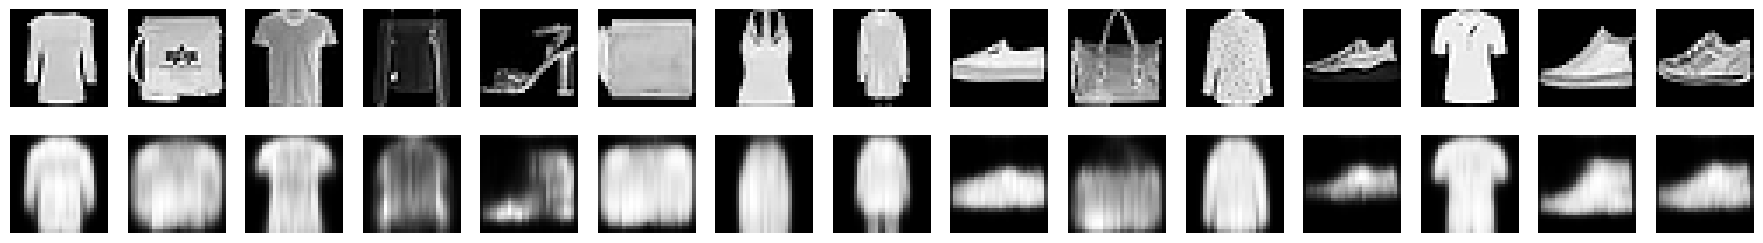

In [53]:
show_reconstructions(recurrent_ae)
plt.show()

# Stacked denoising Autoencoder

In [54]:
# Using Gaussian noise:

tf.random.set_seed(42)
np.random.seed(42)

denoising_encoder = Sequential([
    layers.Input(shape=[28, 28]),
    layers.Flatten(),
    layers.GaussianNoise(0.2),
    layers.Dense(100, activation="selu"),
    layers.Dense(30, activation="selu")
])
denoising_decoder = Sequential([
    layers.Input(shape=[30]),
    layers.Dense(100, activation="selu"),
    layers.Dense(28 * 28, activation="sigmoid"),
    layers.Reshape([28, 28])
])
denoising_ae = Sequential([denoising_encoder, denoising_decoder])

denoising_ae.compile(loss="binary_crossentropy",
                     optimizer=optimizers.SGD(learning_rate=1.0),
                     metrics=[rounded_accuracy])

history = denoising_ae.fit(X_train, X_train,
                           epochs=10,
                           validation_data=(X_valid, X_valid))

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 0.3507 - rounded_accuracy: 0.8771 - val_loss: 0.3194 - val_rounded_accuracy: 0.9058
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 0.3134 - rounded_accuracy: 0.9090 - val_loss: 0.3100 - val_rounded_accuracy: 0.9149
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.3065 - rounded_accuracy: 0.9147 - val_loss: 0.3047 - val_rounded_accuracy: 0.9161
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.3027 - rounded_accuracy: 0.9180 - val_loss: 0.3009 - val_rounded_accuracy: 0.9209
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.3002 - rounded_accuracy: 0.9199 - val_loss: 0.2990 - val_rounded_accuracy: 0.9222
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.2983 - rounded_accuracy: 0.9216 - val_loss: 0.2971 - val_rounded_accuracy: 0.9235
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 0.2969 - rounded_accuracy: 0.9228 - val_loss: 0.2954 - val_

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step


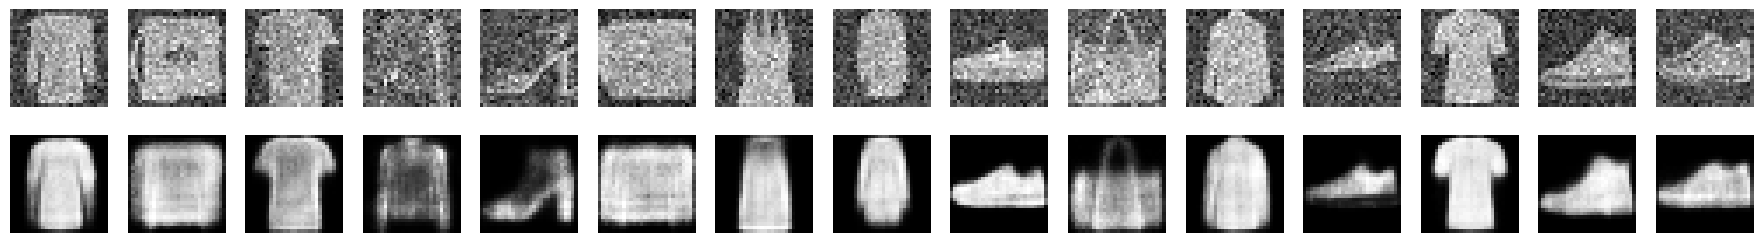

In [55]:
tf.random.set_seed(42)
np.random.seed(42)

noise = layers.GaussianNoise(0.2)
show_reconstructions(denoising_ae, noise(X_valid, training=True))
plt.show()

In [56]:
# Using dropout:
tf.random.set_seed(42)
np.random.seed(42)

dropout_encoder = Sequential([
    layers.Input(shape=[28, 28]),
    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(100, activation="selu"),
    layers.Dense(30, activation="selu")
])
dropout_decoder = Sequential([
    layers.Input(shape=[30]),
    layers.Dense(100, activation="selu"),
    layers.Dense(28 * 28, activation="sigmoid"),
    layers.Reshape([28, 28])
])
dropout_ae = Sequential([dropout_encoder, dropout_decoder])

dropout_ae.compile(loss="binary_crossentropy",
                   optimizer=optimizers.SGD(learning_rate=1.0),
                   metrics=[rounded_accuracy])

history = dropout_ae.fit(X_train, X_train,
                         epochs=10,
                         validation_data=(X_valid, X_valid))

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 0.3569 - rounded_accuracy: 0.8704 - val_loss: 0.3206 - val_rounded_accuracy: 0.9032
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 0.3183 - rounded_accuracy: 0.9031 - val_loss: 0.3121 - val_rounded_accuracy: 0.9099
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.3114 - rounded_accuracy: 0.9086 - val_loss: 0.3060 - val_rounded_accuracy: 0.9167
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.3076 - rounded_accuracy: 0.9117 - val_loss: 0.3021 - val_rounded_accuracy: 0.9194
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.3050 - rounded_accuracy: 0.9139 - val_loss: 0.3019 - val_rounded_accuracy: 0.9206
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.3030 - rounded_accuracy: 0.9156 - val_loss: 0.2983 - val_rounded_accuracy: 0.9234
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.3014 - rounded_accuracy: 0.9169 - val_loss: 0.2967 - val_r

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


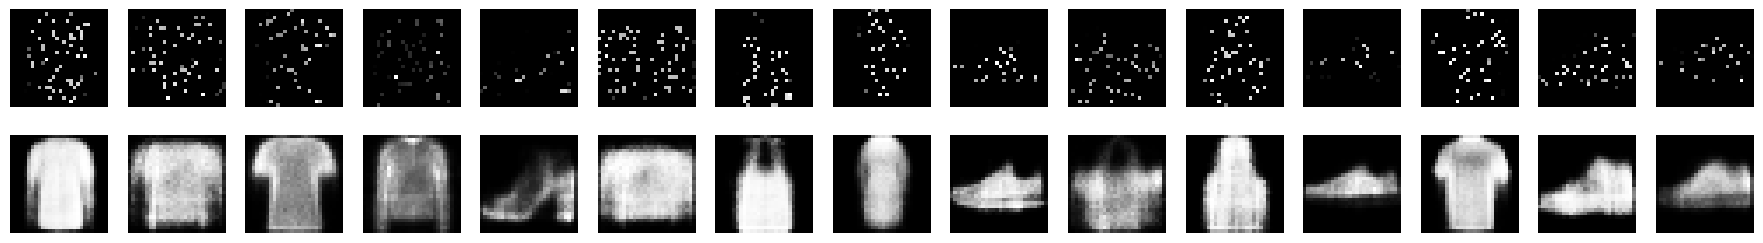

In [61]:
tf.random.set_seed(42)
np.random.seed(42)

dropout = layers.Dropout(0.9) # 90 % dropout !
show_reconstructions(dropout_ae, dropout(X_valid, training=True))

# Sparse Autoencoder

> Let's build a simple stacked autoencoder, so we can compare it to the sparse autoencoders we will build. <br />
> This time we will use the sigmoid activation function for the coding layer, to ensure that the coding values range from 0 to 1:

In [6]:
tf.random.set_seed(42)
np.random.seed(42)

simple_encoder = Sequential([
    layers.Input(shape=[28, 28]),
    layers.Flatten(),
    layers.Dense(100, activation="selu"),
    layers.Dense(30, activation="sigmoid"),
])
simple_decoder = Sequential([
    layers.Input(shape=[30]),
    layers.Dense(100, activation="selu"),
    layers.Dense(28 * 28, activation="sigmoid"),
    layers.Reshape([28, 28])
])
simple_ae = Sequential([simple_encoder, simple_decoder])

simple_ae.compile(loss="binary_crossentropy",
                  optimizer=optimizers.SGD(learning_rate=1.),
                  metrics=[rounded_accuracy])

history = simple_ae.fit(X_train, X_train,
                        epochs=10,
                        validation_data=(X_valid, X_valid))

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - loss: 0.4288 - rounded_accuracy: 0.7990 - val_loss: 0.3736 - val_rounded_accuracy: 0.8543
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 0.3553 - rounded_accuracy: 0.8729 - val_loss: 0.3446 - val_rounded_accuracy: 0.8863
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 0.3335 - rounded_accuracy: 0.8918 - val_loss: 0.3285 - val_rounded_accuracy: 0.8985
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - loss: 0.3225 - rounded_accuracy: 0.9006 - val_loss: 0.3217 - val_rounded_accuracy: 0.9035
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.3180 - rounded_accuracy: 0.9041 - val_loss: 0.3184 - val_rounded_accuracy: 0.9045
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.3151 - rounded_accuracy: 0.9066 - val_loss: 0.3157 - val_rounded_accuracy: 0.9069
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 0.3127 - rounded_accuracy: 0.9087 - val_loss: 0.3132 - val_r

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step


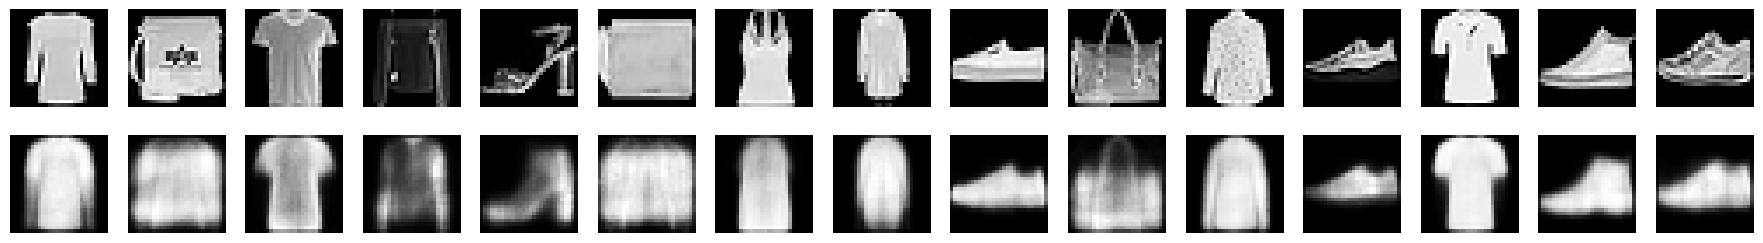

In [9]:
show_reconstructions(simple_ae)
plt.show()

In [10]:
# Let's use these functions to plot histograms of the activations of the encoding layer.
# The histogram on the left shows the distribution of all the activations. You can see that values close to 0 or 1 are more frequent overall,
# which is consistent with the saturating nature of the sigmoid function.
# The histogram on the right shows the distribution of mean neuron activations: you can see that most neurons have a mean activation close to 0.5.
# Both histograms tell us that each neuron tends to either fire close to 0 or 1, with about 50% probability each.
# However, some neurons fire almost all the time (right side of the right histogram).

def plot_percent_hist(ax, data, bins):
    counts, _ = np.histogram(data, bins=bins)
    widths = bins[1:] - bins[:-1]
    x = bins[:-1] + widths / 2
    ax.bar(x, counts / len(data), width=widths*0.8)
    ax.xaxis.set_ticks(bins)
    ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(
        lambda y, position: "{}%".format(int(np.round(100 * y)))))
    ax.grid(True)

def plot_activations_histogram(encoder, height=1., n_bins=10):
    X_valid_codings = encoder(X_valid).numpy()
    activation_means = X_valid_codings.mean(axis=0)
    mean = activation_means.mean()
    bins = np.linspace(0, 1, n_bins + 1)

    fig, [ax1, ax2] = plt.subplots(figsize=(10, 3), nrows=1, ncols=2, sharey=True)
    plot_percent_hist(ax1, X_valid_codings.ravel(), bins)
    ax1.plot([mean, mean], [0, height], "k--", label="Overall Mean = {:.2f}".format(mean))
    ax1.legend(loc="upper center", fontsize=14)
    ax1.set_xlabel("Activation")
    ax1.set_ylabel("% Activations")
    ax1.axis([0, 1, 0, height])
    plot_percent_hist(ax2, activation_means, bins)
    ax2.plot([mean, mean], [0, height], "k--")
    ax2.set_xlabel("Neuron Mean Activation")
    ax2.set_ylabel("% Neurons")
    ax2.axis([0, 1, 0, height])

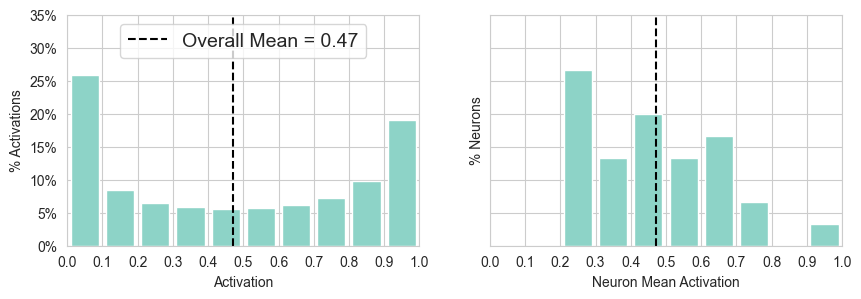

In [11]:
plot_activations_histogram(simple_encoder, height=0.35)
plt.show()

In [12]:
# Now let's add l1 regularization to the coding layer:

tf.random.set_seed(42)
np.random.seed(42)

sparse_l1_encoder = Sequential([
    layers.Input(shape=[28, 28]),
    layers.Flatten(),
    layers.Dense(100, activation="selu"),
    layers.Dense(300, activation="sigmoid"),
    layers.ActivityRegularization(l1=1e-3)  # Alternatively, you could add
                                                  # activity_regularizer=regularizers.l1(1e-3)
                                                  # to the previous layer.
])
sparse_l1_decoder = Sequential([
    layers.Input(shape=[300]),
    layers.Dense(100, activation="selu"),
    layers.Dense(28 * 28, activation="sigmoid"),
    layers.Reshape([28, 28])
])
sparse_l1_ae = Sequential([sparse_l1_encoder,
                           sparse_l1_decoder])

sparse_l1_ae.compile(loss="binary_crossentropy",
                     optimizer=optimizers.SGD(learning_rate=1.0),
                     metrics=[rounded_accuracy])

history = sparse_l1_ae.fit(X_train, X_train,
                           epochs=10,
                           validation_data=(X_valid, X_valid))

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - loss: 0.5235 - rounded_accuracy: 0.7258 - val_loss: 0.4934 - val_rounded_accuracy: 0.7289
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.4905 - rounded_accuracy: 0.7311 - val_loss: 0.4929 - val_rounded_accuracy: 0.7289
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.4903 - rounded_accuracy: 0.7311 - val_loss: 0.4928 - val_rounded_accuracy: 0.7289
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 0.4902 - rounded_accuracy: 0.7311 - val_loss: 0.4927 - val_rounded_accuracy: 0.7289
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.4902 - rounded_accuracy: 0.7311 - val_loss: 0.4927 - val_rounded_accuracy: 0.7289
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.4901 - rounded_accuracy: 0.7311 - val_loss: 0.4927 - val_rounded_accuracy: 0.7289
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 0.4901 - rounded_accuracy: 0.7311 - val_loss: 0.4927 - val_ro

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step


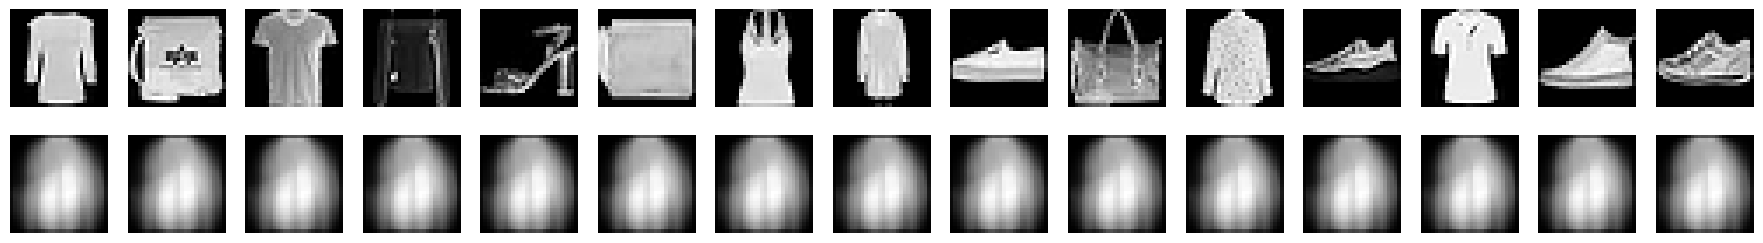

In [13]:
show_reconstructions(sparse_l1_ae)

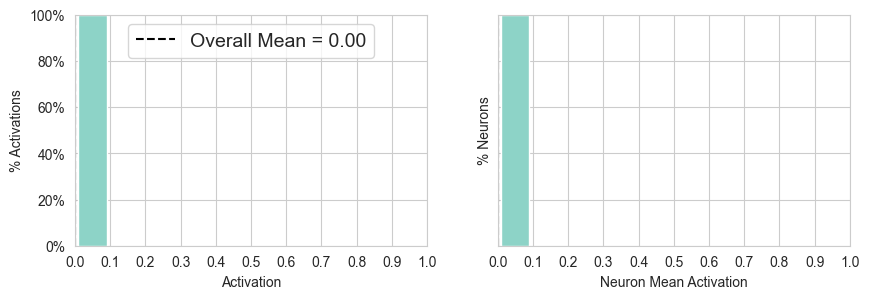

In [14]:
plot_activations_histogram(sparse_l1_encoder, height=1.)
plt.show()

(np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(0.95))

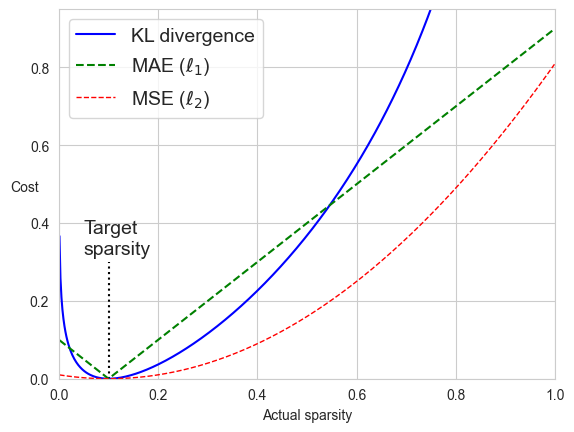

In [17]:
# Let's use the KL Divergence loss instead to ensure sparsity, and target 10% sparsity rather than 0%:

p = 0.1
q = np.linspace(0.001, 0.999, 500)
kl_div = p * np.log(p / q) + (1 - p) * np.log((1 - p) / (1 - q))
mse = (p - q)**2
mae = np.abs(p - q)
plt.plot([p, p], [0, 0.3], "k:")
plt.text(0.05, 0.32, "Target\nsparsity", fontsize=14)
plt.plot(q, kl_div, "b-", label="KL divergence")
plt.plot(q, mae, "g--", label=r"MAE ($\ell_1$)")
plt.plot(q, mse, "r--", linewidth=1, label=r"MSE ($\ell_2$)")
plt.legend(loc="upper left", fontsize=14)
plt.xlabel("Actual sparsity")
plt.ylabel("Cost", rotation=0)
plt.axis((0, 1, 0, 0.95))

In [20]:
K = tf.backend
kl_divergence = losses.kullback_leibler_divergence

class KLDivergenceRegularizer(regularizers.Regularizer):
    """ KL divergence regularizer to encourage sparsity."""
    def __init__(self, weight, target=0.1):
        self.weight = weight
        self.target = target
    def __call__(self, inputs):
        mean_activities = K.mean(inputs, axis=0)
        return self.weight * (
                kl_divergence(self.target, mean_activities) +
                kl_divergence(1. - self.target, 1. - mean_activities))

tf.random.set_seed(42)
np.random.seed(42)

kld_reg = KLDivergenceRegularizer(weight=0.05, target=0.1)
sparse_kl_encoder = Sequential([
    layers.Input(shape=[28, 28]),
    layers.Flatten(),
    layers.Dense(100, activation="selu"),
    layers.Dense(300, activation="sigmoid", activity_regularizer=kld_reg)
])
sparse_kl_decoder = Sequential([
    layers.Input(shape=[300]),
    layers.Dense(100, activation="selu"),
    layers.Dense(28 * 28, activation="sigmoid"),
    layers.Reshape([28, 28])
])
sparse_kl_ae = Sequential([sparse_kl_encoder,
                           sparse_kl_decoder])

sparse_kl_ae.compile(loss="binary_crossentropy",
                     optimizer=optimizers.SGD(learning_rate=1.0),
                     metrics=[rounded_accuracy])

history = sparse_kl_ae.fit(X_train, X_train,
                           epochs=10,
                           validation_data=(X_valid, X_valid))

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - loss: 0.4792 - rounded_accuracy: 0.7857 - val_loss: 0.4288 - val_rounded_accuracy: 0.8151
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.3895 - rounded_accuracy: 0.8443 - val_loss: 0.4042 - val_rounded_accuracy: 0.8280
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.3756 - rounded_accuracy: 0.8611 - val_loss: 0.3816 - val_rounded_accuracy: 0.8536
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 0.3591 - rounded_accuracy: 0.8793 - val_loss: 0.3711 - val_rounded_accuracy: 0.8566
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.3481 - rounded_accuracy: 0.8883 - val_loss: 0.3628 - val_rounded_accuracy: 0.8623
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.3394 - rounded_accuracy: 0.8950 - val_loss: 0.3539 - val_rounded_accuracy: 0.8711
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 0.3341 - rounded_accuracy: 0.8983 - val_loss: 0.3492 - val_r

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step


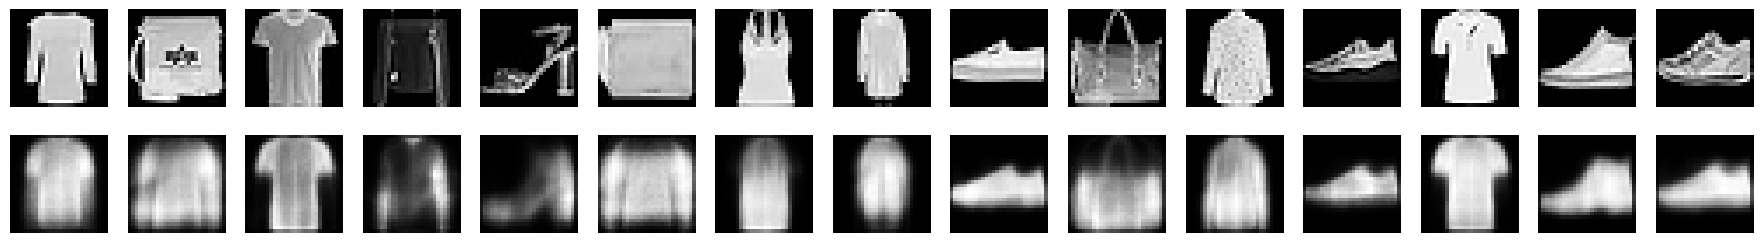

In [21]:
show_reconstructions(sparse_kl_ae)

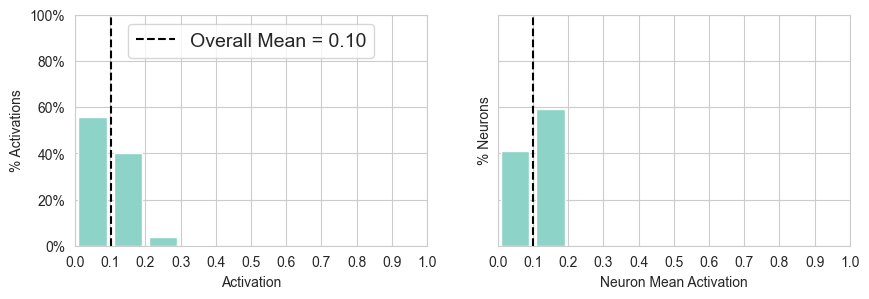

In [23]:
plot_activations_histogram(sparse_kl_encoder)

# Variational Autoencoder

In [7]:
from keras import ops

tf.random.set_seed(42)
np.random.seed(42)
codings_size = 10

class Sampling(layers.Layer):
    def call(self, inputs):
        mean, log_var = inputs
        eps = tf.random.normal(shape=tf.shape(log_var), dtype=log_var.dtype)
        z = mean + tf.exp(0.5 * log_var) * eps

        kl_loss = -0.5 * ops.sum(
            1 + log_var - ops.exp(log_var) - ops.square(mean),
            axis=-1
        )

        self.add_loss(ops.mean(kl_loss) / 784.0)
        return z

def kl_divergence_loss(mean, log_var):
    return -0.5 * ops.sum(
        1 + log_var - ops.exp(log_var) - ops.square(mean),
        axis=-1
    )

inputs = layers.Input(shape=[28, 28])
z = layers.Flatten()(inputs)
z = layers.Dense(150, activation="selu")(z)
z = layers.Dense(100, activation="selu")(z)

codings_mean = layers.Dense(codings_size)(z)
codings_log_var = layers.Dense(codings_size)(z)
codings = Sampling()([codings_mean, codings_log_var])

variational_encoder = Model(
    inputs=[inputs], outputs=[codings_mean, codings_log_var, codings])


decoder_inputs = layers.Input(shape=[codings_size])
x = layers.Dense(100, activation="selu")(decoder_inputs)
x = layers.Dense(150, activation="selu")(x)
x = layers.Dense(28 * 28, activation="sigmoid")(x)
outputs = layers.Reshape([28, 28])(x)
variational_decoder = Model(inputs=[decoder_inputs], outputs=[outputs])

codings_mean, codings_log_var, codings = variational_encoder(inputs)
reconstructions = variational_decoder(codings)
variational_ae = Model(inputs=inputs, outputs=reconstructions)

variational_ae.compile(loss="binary_crossentropy",
                       optimizer="rmsprop",
                       metrics=[rounded_accuracy])

history = variational_ae.fit(X_train, X_train,
                             epochs=25,
                             batch_size=128,
                             validation_data=(X_valid, X_valid))


Epoch 1/25
430/430 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - loss: 0.4138 - rounded_accuracy: 0.8372 - val_loss: 0.3791 - val_rounded_accuracy: 0.8643
Epoch 2/25
430/430 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - loss: 0.3560 - rounded_accuracy: 0.8890 - val_loss: 0.3538 - val_rounded_accuracy: 0.8945
Epoch 3/25
430/430 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss: 0.3442 - rounded_accuracy: 0.8975 - val_loss: 0.3469 - val_rounded_accuracy: 0.8990
Epoch 4/25
430/430 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - loss: 0.3377 - rounded_accuracy: 0.9026 - val_loss: 0.3391 - val_rounded_accuracy: 0.8978
Epoch 5/25
430/430 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - loss: 0.3335 - rounded_accuracy: 0.9056 - val_loss: 0.3327 - val_rounded_accuracy: 0.9087
Epoch 6/25
430/430 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 0.3306 - rounded_accuracy: 0.9078 - val_loss: 0.3351 - val_rounded_accuracy: 0.9070
Epoch 7/25
430/430 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 0.3282 - rounded_accuracy: 0.9096 - val_loss: 0.3298 - val_rounded_

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step


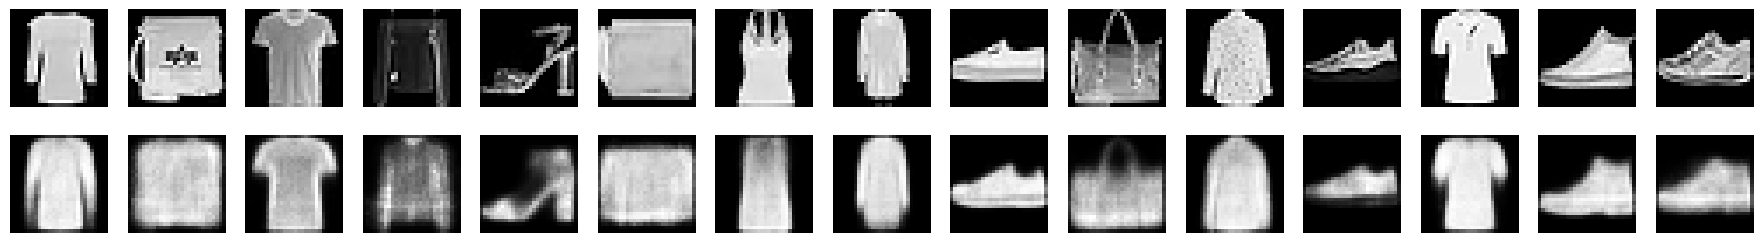

In [35]:
show_reconstructions(variational_ae)

# Generate Fashion Images

In [8]:
def plot_multiple_images(images, n_cols=None):
    n_cols = n_cols or len(images)
    n_rows = (len(images) - 1) // n_cols + 1
    if images.shape[-1] == 1:
        images = np.squeeze(images, axis=-1)
    plt.figure(figsize=(n_cols, n_rows))
    for index, image in enumerate(images):
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(image, cmap="binary")
        plt.axis("off")

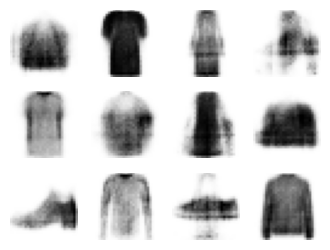

In [9]:
# Let's generate a few random codings, decode them and plot the resulting images:

codings = tf.random.normal(shape=[12, codings_size])
images = variational_decoder(codings).numpy()
plot_multiple_images(images, 4)

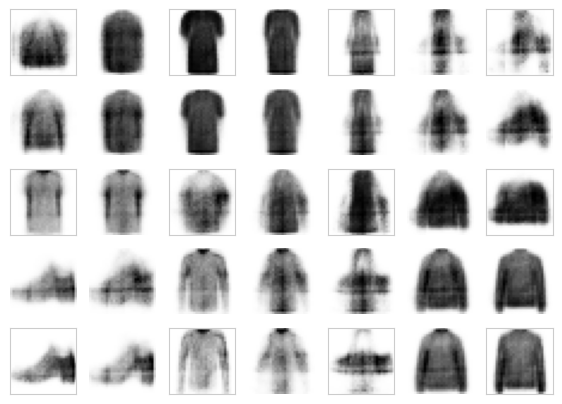

In [10]:
# Now let's perform semantic interpolation between these images:

tf.random.set_seed(42)
np.random.seed(42)

codings_grid = tf.reshape(codings, [1, 3, 4, codings_size])
larger_grid = tf.image.resize(codings_grid, size=[5, 7])
interpolated_codings = tf.reshape(larger_grid, [-1, codings_size])
images = variational_decoder(interpolated_codings).numpy()

plt.figure(figsize=(7, 5))
for index, image in enumerate(images):
    plt.subplot(5, 7, index + 1)
    if index % 7 % 2 == 0 and index // 7 % 2 == 0:
        plt.gca().get_xaxis().set_visible(False)
        plt.gca().get_yaxis().set_visible(False)
    else:
        plt.axis("off")
    plt.imshow(image, cmap="binary")

# Generative Adversarial Networks

In [13]:
np.random.seed(42)
tf.random.set_seed(42)

codings_size = 30

generator = Sequential([
    layers.Input(shape=[codings_size]),
    layers.Dense(100, activation="selu"),
    layers.Dense(150, activation="selu"),
    layers.Dense(28 * 28, activation="sigmoid"),
    layers.Reshape([28, 28])
])
discriminator = Sequential([
    layers.Input(shape=[28, 28]),
    layers.Flatten(),
    layers.Dense(150, activation="selu"),
    layers.Dense(100, activation="selu"),
    layers.Dense(1, activation="sigmoid")
])
gan = Sequential([generator, discriminator])

In [14]:
discriminator.compile(loss="binary_crossentropy", optimizer="rmsprop")
discriminator.trainable = False
gan.compile(loss="binary_crossentropy", optimizer="rmsprop")

In [15]:
batch_size = 32
dataset = tf.data.Dataset.from_tensor_slices(X_train).shuffle(1000)
dataset = dataset.batch(batch_size, drop_remainder=True).prefetch(1)


In [16]:
def train_gan(gan, dataset, batch_size, codings_size, n_epochs=50):
    generator, discriminator = gan.layers
    for epoch in range(n_epochs):
        print("Epoch {}/{}".format(epoch + 1, n_epochs))              # not shown in the book
        for X_batch in dataset:
            # phase 1 - training the discriminator
            noise = tf.random.normal(shape=[batch_size, codings_size])
            generated_images = generator(noise)
            X_fake_and_real = tf.concat([generated_images, X_batch], axis=0)
            y1 = tf.constant([[0.]] * batch_size + [[1.]] * batch_size)
            discriminator.trainable = True
            discriminator.train_on_batch(X_fake_and_real, y1)
            # phase 2 - training the generator
            noise = tf.random.normal(shape=[batch_size, codings_size])
            y2 = tf.constant([[1.]] * batch_size)
            discriminator.trainable = False
            gan.train_on_batch(noise, y2)
        plot_multiple_images(generated_images, 8)                     # not shown
        plt.show()                                                    # not shown

Epoch 1/1


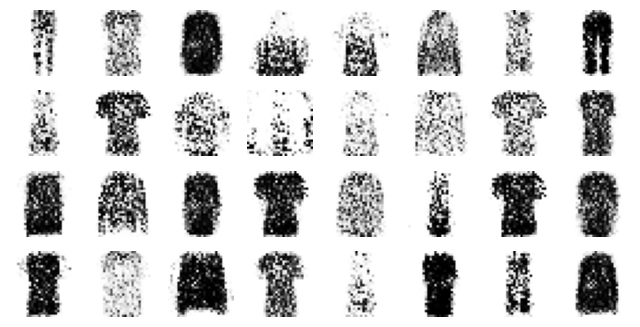

In [17]:
train_gan(gan, dataset, batch_size, codings_size, n_epochs=1)

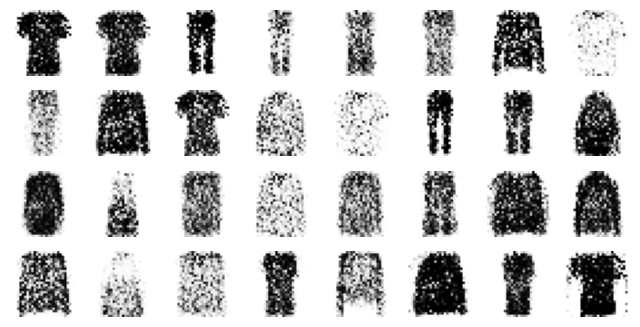

In [18]:
tf.random.set_seed(42)
np.random.seed(42)

noise = tf.random.normal(shape=[batch_size, codings_size])
generated_images = generator(noise)
plot_multiple_images(generated_images, 8)


# Deep Convolutional GAN

In [19]:
tf.random.set_seed(42)
np.random.seed(42)

codings_size = 100

generator = Sequential([
    layers.Input(shape=[codings_size]),
    layers.Dense(7 * 7 * 128),
    layers.Reshape([7, 7, 128]),
    layers.BatchNormalization(),
    layers.Conv2DTranspose(64,
                           kernel_size=5,
                           strides=2,
                           padding="SAME",
                           activation="selu"),
    layers.BatchNormalization(),
    layers.Conv2DTranspose(1,
                           kernel_size=5,
                           strides=2,
                           padding="SAME",
                           activation="tanh"),
])
discriminator = Sequential([
    layers.Input(shape=[28, 28, 1]),
    layers.Conv2D(64,
                  kernel_size=5,
                  strides=2,
                  padding="SAME",
                  activation=layers.LeakyReLU(0.2)),
    layers.Dropout(0.4),
    layers.Conv2D(128,
                  kernel_size=5,
                  strides=2,
                  padding="SAME",
                  activation=layers.LeakyReLU(0.2)),
    layers.Dropout(0.4),
    layers.Flatten(),
    layers.Dense(1, activation="sigmoid")
])
gan = Sequential([generator, discriminator])

discriminator.compile(loss="binary_crossentropy", optimizer="rmsprop")
discriminator.trainable = False
gan.compile(loss="binary_crossentropy", optimizer="rmsprop")

In [22]:
X_train_dcgan = X_train.reshape(-1, 28, 28, 1) * 2. - 1. # reshape and rescale

batch_size = 32
dataset = tf.data.Dataset.from_tensor_slices(X_train_dcgan)
dataset = dataset.shuffle(1000)
dataset = dataset.batch(batch_size, drop_remainder=True).prefetch(1)

In [ ]:
train_gan(gan, dataset, batch_size, codings_size, 5)

Epoch 1/50


In [ ]:
tf.random.set_seed(42)
np.random.seed(42)

noise = tf.random.normal(shape=[batch_size, codings_size])
generated_images = generator(noise)
plot_multiple_images(generated_images, 8)

# Extra Material
Hashing Using a Binary Autoencoder

In [ ]:
# Let's load the Fashion MNIST dataset again:

(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()
X_train_full = X_train_full.astype(np.float32) / 255
X_test = X_test.astype(np.float32) / 255
X_train, X_valid = X_train_full[:-5000], X_train_full[-5000:]
y_train, y_valid = y_train_full[:-5000], y_train_full[-5000:]

> Let's train an autoencoder where the encoder has a 16-neuron output layer, using the sigmoid activation function, and heavy Gaussian noise just before it. During training, the noise layer will encourage the previous layer to learn to output large values, since small values will just be crushed by the noise. In turn, this means that the output layer will output values close to 0 or 1, thanks to the sigmoid activation function. Once we round the output values to 0s and 1s, we get a 16-bit "semantic" hash. If everything works well, images that look alike will have the same hash. This can be very useful for search engines: for example, if we store each image on a server identified by the image's semantic hash, then all similar images will end up on the same server. Users of the search engine can then provide an image to search for, and the search engine will compute the image's hash using the encoder, and quickly return all the images on the server identified by that hash.

In [ ]:
tf.random.set_seed(42)
np.random.seed(42)

hashing_encoder = Sequential([
    layers.Flatten(input_shape=[28, 28]),
    layers.Dense(100, activation="selu"),
    layers.GaussianNoise(15.),
    layers.Dense(16, activation="sigmoid"),
])
hashing_decoder = Sequential([
    layers.Dense(100, activation="selu", input_shape=[16]),
    layers.Dense(28 * 28, activation="sigmoid"),
    layers.Reshape([28, 28])
])
hashing_ae = Sequential([hashing_encoder, hashing_decoder])
hashing_ae.compile(loss="binary_crossentropy", optimizer=optimizers.Nadam(),
                   metrics=[rounded_accuracy])
history = hashing_ae.fit(X_train, X_train, epochs=10,
                         validation_data=(X_valid, X_valid))

In [ ]:
show_reconstructions(hashing_ae)
plt.show()

In [ ]:
# Notice that the outputs are indeed very close to 0 or 1 (left graph):
plot_activations_histogram(hashing_encoder)
plt.show()

In [ ]:
# Now let's see what the hashes look like for the first few images in the validation set:

hashes = np.round(hashing_encoder.predict(X_valid)).astype(np.int32)
hashes *= np.array([[2**bit for bit in range(16)]])
hashes = hashes.sum(axis=1)
for h in hashes[:5]:
    print("{:016b}".format(h))
print("...")

In [ ]:
# Now let's find the most common image hashes in the validation set, and display a few images for each hash. In the following image, all the images on a given row have the same hash:


n_hashes = 10
n_images = 8

top_hashes = Counter(hashes).most_common(n_hashes)

plt.figure(figsize=(n_images, n_hashes))
for hash_index, (image_hash, hash_count) in enumerate(top_hashes):
    indices = (hashes == image_hash)
    for index, image in enumerate(X_valid[indices][:n_images]):
        plt.subplot(n_hashes, n_images, hash_index * n_images + index + 1)
        plt.imshow(image, cmap="binary")
        plt.axis("off")